# TASK 36: Convolutional Neural Network for Image Classification

## Loading dataset

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the paths to the dataset
train_dir = '/kaggle/input/fruits/Fruits/train'
test_dir = '/kaggle/input/fruits/Fruits/test'

# Create ImageDataGenerators for training and testing data
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical'
)


Found 706 images belonging to 2 classes.
Found 176 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


## Building CNN

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(100, 100, 3)),  # Define input shape
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(train_generator.class_indices), activation='softmax')
])


## Compile

In [17]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


## Train

In [18]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 321ms/step - accuracy: 0.7586 - loss: 0.4145 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 332ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 307ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 308ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 324ms/ste

## Evaluate

In [19]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test accuracy: 1.0


## Save and load

In [20]:
model.save('fruits_cnn_model.h5')


In [21]:
from tensorflow.keras.models import load_model
model = load_model('fruits_cnn_model.h5')


## Visualize

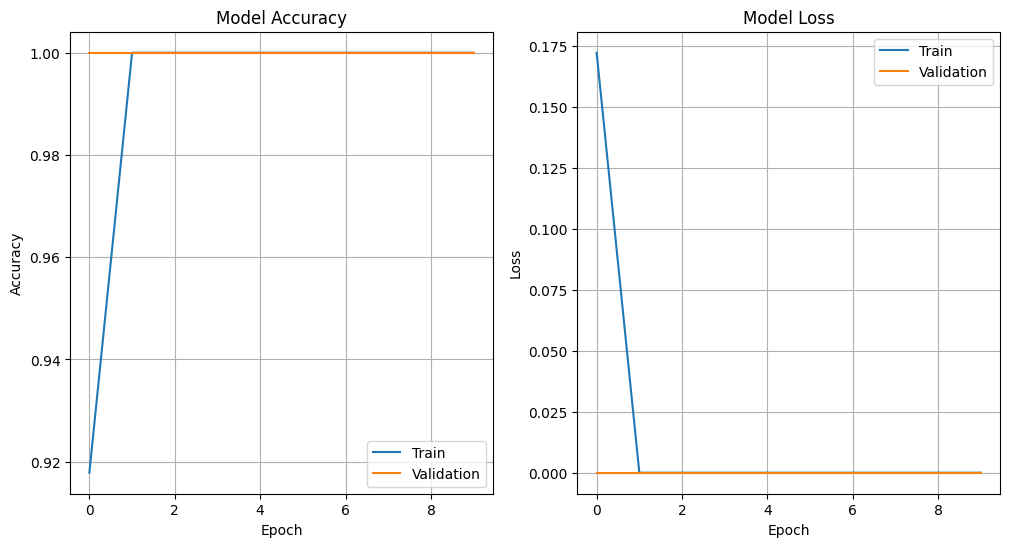

In [23]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.grid(True)

plt.show()
